<a href="https://colab.research.google.com/github/Trondster/CS4140//blob/main/train/drone-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install "tensorflow==2.19.0" tf-keras tensorflow-model-optimization ai-edge-litert -q

In [37]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import random

import tensorflow as tf
import tf_keras as keras
from tf_keras import layers
import tensorflow_model_optimization as tfmot
from ai_edge_litert import interpreter as litert

print("TensorFlow:", tf.__version__)
print("Keras (legacy):", keras.__version__)

TensorFlow: 2.19.0
Keras (legacy): 2.19.0


# Extract zip

In [38]:
import os
import zipfile
from google.colab import drive
drive.mount('/content/drive')

DATASET_TO_USE = '2x2'

zip_file_path = 'drive/MyDrive/Embedded AI/dataset.zip'

# Define the root directory where the selected folders will be extracted.
extract_root_path = '.'

# Ensure the top-level 'dataset' folder exists within the extract_root_path
os.makedirs(os.path.join(extract_root_path, 'dataset'), exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        all_members = zip_ref.namelist()

        # Define the prefixes for the subfolders you want to extract
        target_prefixes = [f'dataset/{DATASET_TO_USE}/', 'dataset/labels/']

        members_to_extract = []
        for member in all_members:
            for prefix in target_prefixes:
                if member.startswith(prefix) or member == prefix.rstrip('/'): # Include the directory itself
                    members_to_extract.append(member)
                    break

        print(f"Extracting {len(members_to_extract)} selected items from '{zip_file_path}'...")

        # Extract only the selected members
        for member in members_to_extract:
            zip_ref.extract(member, path=extract_root_path)

    print(f"Successfully extracted selected subfolders to '{extract_root_path}'")

    # List the contents of the target 'dataset' folder to verify
    target_list_path = os.path.join(extract_root_path, 'dataset')
    print(f"Contents of '{target_list_path}':")
    for root, dirs, files in os.walk(target_list_path):
        level = root.replace(target_list_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')

except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found. Please check the path.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting 3186 selected items from 'drive/MyDrive/Embedded AI/dataset.zip'...
Successfully extracted selected subfolders to '.'
Contents of './dataset':
dataset/
    2x2/
        drone/
        clear/
    labels/


In [39]:
import glob

# Define the paths to your image folders
drone_path = f'dataset/{DATASET_TO_USE}/drone'
clear_path = f'dataset/{DATASET_TO_USE}/clear'

# Get all image file paths from both folders
drone_images = glob.glob(os.path.join(drone_path, '*.png'))
clear_images = glob.glob(os.path.join(clear_path, '*.png'))

print(f"Found {len(drone_images)} drone images.")
print(f"Found {len(clear_images)} clear images.")

all_images = drone_images + clear_images
random.shuffle(all_images)

print(f"Total of {len(all_images)} images for training.")

Found 1078 drone images.
Found 1045 clear images.
Total of 2123 images for training.


The image filenames follow a pattern: `ID_type_frame.png` (e.g., `4407882_drone_current_frame.png`). For each unique `ID`, there should be a `_current_frame.png` and a `_diff_frame.png` image, and a corresponding `ID.txt` file in the `dataset/labels` folder. This `ID.txt` file contains the ground truth label (0 for clear, 1 for drone) and bounding box information.

We will now process all image paths to:
1.  Identify pairs of `current_frame` and `diff_frame` images based on their unique ID.
2.  Locate and read the corresponding `ID.txt` label file.
3.  Extract the label (first value in the `.txt` file) and bounding box data.
4.  Create a list `X` where each element is a tuple `(path_to_current_frame, path_to_diff_frame)`.
5.  Create a list `y` where each element is the integer label for the corresponding image pair.

In [40]:
import os
import glob
import random

# Combine all image paths from drone and clear categories
all_image_paths = drone_images + clear_images

# Dictionary to store image pairs and their label file path
image_pairs_data = {}

for img_path in all_image_paths:
    # Extract filename without extension
    basename = os.path.basename(img_path)
    filename_without_ext = os.path.splitext(basename)[0]

    # Extract unique ID and frame type
    # Example: '4407882_drone_current_frame' -> ID '4407882', frame_type 'current_frame'
    parts = filename_without_ext.split('_')
    image_id = parts[0]
    frame_type = '_'.join(parts[-2:]) # 'current_frame' or 'diff_frame'

    if image_id not in image_pairs_data:
        image_pairs_data[image_id] = {
            'current_frame': None,
            'diff_frame': None,
            'label_bbox': None # To store the (label, bbox) tuple
        }

    if 'current_frame' in frame_type:
        image_pairs_data[image_id]['current_frame'] = img_path
    elif 'diff_frame' in frame_type:
        image_pairs_data[image_id]['diff_frame'] = img_path

# Now, go through the image_pairs_data to find complete pairs and read labels
X_paired = [] # List of (current_frame_path, diff_frame_path)
y_labels_and_bboxes = [] # List of (integer label, bounding box data) tuples

label_dir = 'dataset/labels' # Directory where label .txt files are located

for image_id, data in image_pairs_data.items():
    current_frame_path = data.get('current_frame')
    diff_frame_path = data.get('diff_frame')

    # Only process if both current and diff frames are found for this ID
    if current_frame_path and diff_frame_path:
        label_file_path = os.path.join(label_dir, f"{image_id}.txt")

        if os.path.exists(label_file_path):
            try:
                with open(label_file_path, 'r') as f:
                    # Assuming the format in .txt is: label_id bbox_x bbox_y bbox_width bbox_height
                    line = f.readline().strip()
                    parts = line.split()
                    if parts:
                        label = int(parts[0]) # The first value is the class label (0 or 1)
                        # If no bounding box is present (e.g., for clear images where bbox is not relevant or missing),
                        # default to [0.0, 0.0, 0.0, 0.0] for consistency in tuple structure.
                        bbox = [float(p) for p in parts[1:]] if len(parts) > 1 else [0.0, 0.0, 0.0, 0.0]

                        X_paired.append((current_frame_path, diff_frame_path))
                        y_labels_and_bboxes.append((label, bbox))
            except Exception as e:
                print(f"Error reading label file {label_file_path}: {e}")
        else:
            print(f"Warning: Label file not found for ID {image_id} at {label_file_path}")

# Shuffle the paired data and labels/bboxes together to maintain correspondence
combined_data = list(zip(X_paired, y_labels_and_bboxes))
random.shuffle(combined_data)

# Unpack combined_data. X will be a list of (current_frame_path, diff_frame_path) tuples.
# y_combined will be a list of (label, bbox) tuples.
X, y_combined = zip(*combined_data)
X = list(X)
y_combined = list(y_combined) # This is the list of (label, bbox) tuples

# Separate y_combined into classification labels and bounding box coordinates for model training
y_classification = [item[0] for item in y_combined]
y_bounding_box = [item[1] for item in y_combined]

print(f"Found {len(X)} complete image pairs with labels and bounding boxes.")
print(f"First 5 X (image pairs): {X[:5]}")
print(f"First 5 y_combined (labels and bboxes): {y_combined[:5]}")
print(f"First 5 y_classification (labels only): {y_classification[:5]}")
print(f"First 5 y_bounding_box (bboxes only): {y_bounding_box[:5]}")


Found 1055 complete image pairs with labels and bounding boxes.
First 5 X (image pairs): [('dataset/2x2/drone/938796_drone_current_frame.png', 'dataset/2x2/drone/938796_drone_diff_frame.png'), ('dataset/2x2/drone/4619747_drone_current_frame.png', 'dataset/2x2/drone/4619747_drone_diff_frame.png'), ('dataset/2x2/drone/2845292_drone_current_frame.png', 'dataset/2x2/drone/2845292_drone_diff_frame.png'), ('dataset/2x2/clear/1352797_clear_current_frame.png', 'dataset/2x2/clear/1352797_clear_diff_frame.png'), ('dataset/2x2/clear/3834037_clear_current_frame.png', 'dataset/2x2/clear/3834037_clear_diff_frame.png')]
First 5 y_combined (labels and bboxes): [(1, [0.225, 0.494778, 0.2125, 0.077778]), (1, [0.652083, 0.792, 0.220833, 0.138889]), (1, [0.730208, 0.245111, 0.197917, 0.125]), (0, [0.0, 0.0, 0.0, 0.0]), (0, [0.0, 0.0, 0.0, 0.0])]
First 5 y_classification (labels only): [1, 1, 1, 0, 0]
First 5 y_bounding_box (bboxes only): [[0.225, 0.494778, 0.2125, 0.077778], [0.652083, 0.792, 0.220833, 0.

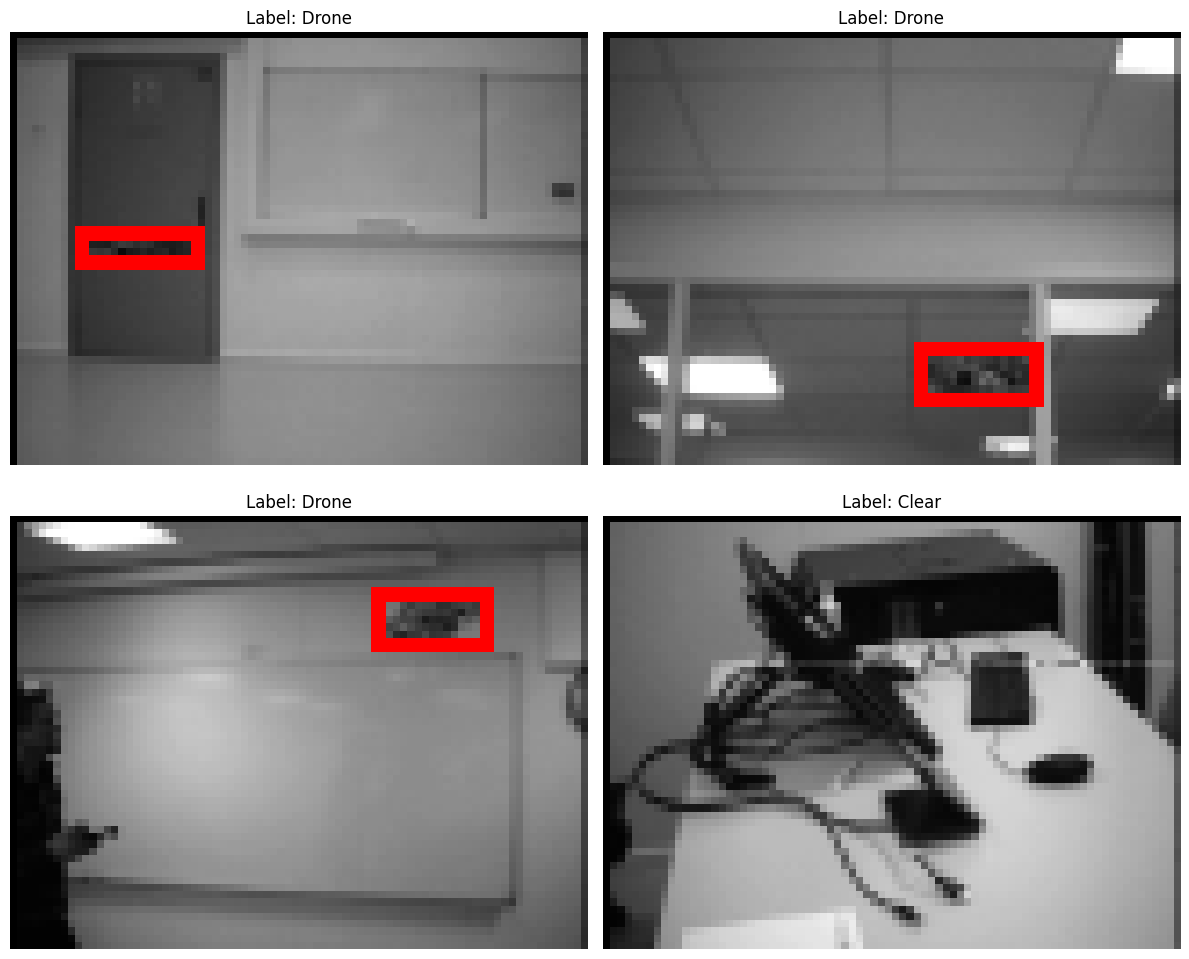

In [41]:
from PIL import Image, ImageDraw
import random
import matplotlib.pyplot as plt

def visualize_samples_with_bbox(X, y_combined, num_samples=4):
    plt.figure(figsize=(12, 10))
    # Show the first 'num_samples' images instead of random sampling
    sample_indices = range(min(num_samples, len(X)))

    for i, idx in enumerate(sample_indices):
        current_frame_path, _ = X[idx]
        label, bbox = y_combined[idx]

        # Load the current frame image
        img = Image.open(current_frame_path).convert('RGB')

        # If it's a drone, draw the bounding box
        if label == 1 and bbox and any(b > 0 for b in bbox): # Check if it's a drone and bbox data exists and is not [0,0,0,0]
            draw = ImageDraw.Draw(img)
            img_width, img_height = img.size

            # Convert normalized bbox to absolute coordinates
            # Bbox format: [x_center, y_center, box_width, box_height]
            x_center, y_center, box_width, box_height = bbox

            # Convert to (x_min, y_min, x_max, y_max)
            x_min = int((x_center - box_width / 2) * img_width)
            y_min = int((y_center - box_height / 2) * img_height)
            x_max = int((x_center + box_width / 2) * img_width)
            y_max = int((y_center + box_height / 2) * img_height)

            draw.rectangle([(x_min, y_min), (x_max, y_max)], outline='red', width=2)

        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {'Drone' if label == 1 else 'Clear'}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples_with_bbox(X, y_combined, num_samples=4)


Now that the image paths and labels are consolidated in `X` and `y`, the next step is to split them into training, validation, and testing sets. We will use `sklearn.model_selection.train_test_split` for this.

In [42]:
from sklearn.model_selection import train_test_split

# Combine X, y_classification, and y_bounding_box into a single list of tuples
# to ensure consistent splitting
combined_data_for_split = list(zip(X, y_classification, y_bounding_box))

# Split combined data into training and temporary sets (80% train, 20% temp)
# Stratify by classification label to maintain class distribution
train_data, temp_data = train_test_split(
    combined_data_for_split, test_size=0.2, random_state=42,
    stratify=y_classification
)

# Split temporary set into validation and test sets (50% validation, 50% test of the 20% temp)
# Stratify temp_data by its classification label (the second element in each tuple)
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42,
    stratify=[item[1] for item in temp_data]
)

# Unpack the split data
X_train, y_classification_train, y_bbox_train = zip(*train_data)
X_val, y_classification_val, y_bbox_val = zip(*val_data)
X_test, y_classification_test, y_bbox_test = zip(*test_data)

X_train = list(X_train)
y_classification_train = list(y_classification_train)
y_bbox_train = list(y_bbox_train)

X_val = list(X_val)
y_classification_val = list(y_classification_val)
y_bbox_val = list(y_bbox_val)

X_test = list(X_test)
y_classification_test = list(y_classification_test)
y_bbox_test = list(y_bbox_test)

print(f"Train set size: {len(X_train)} images")
print(f"Validation set size: {len(X_val)} images")
print(f"Test set size: {len(X_test)} images")

# Example prints for verification
print(f"First 5 X_train (image pairs): {X_train[:5]}")
print(f"First 5 y_classification_train (labels only): {y_classification_train[:5]}")
print(f"First 5 y_bbox_train (bboxes only): {y_bbox_train[:5]}")

Train set size: 844 images
Validation set size: 105 images
Test set size: 106 images
First 5 X_train (image pairs): [('dataset/2x2/clear/2096252_clear_current_frame.png', 'dataset/2x2/clear/2096252_clear_diff_frame.png'), ('dataset/2x2/clear/532478_clear_current_frame.png', 'dataset/2x2/clear/532478_clear_diff_frame.png'), ('dataset/2x2/clear/3537267_clear_current_frame.png', 'dataset/2x2/clear/3537267_clear_diff_frame.png'), ('dataset/2x2/drone/729103_drone_current_frame.png', 'dataset/2x2/drone/729103_drone_diff_frame.png'), ('dataset/2x2/clear/3250157_clear_current_frame.png', 'dataset/2x2/clear/3250157_clear_diff_frame.png')]
First 5 y_classification_train (labels only): [0, 0, 0, 1, 0]
First 5 y_bbox_train (bboxes only): [[0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0], [0.476042, 0.482278, 0.84375, 0.352778], [0.0, 0.0, 0.0, 0.0]]


In [43]:
import tensorflow as tf

# --- Configuration for image processing ---
# InputWidth and InputHeight are already defined globally
BATCH_SIZE = 32

# Function to preprocess a single image path
def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    # Decode PNG as grayscale (channels=1)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [InputHeight, InputWidth])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]
    return img

# Function to load and preprocess a paired data point
def load_and_preprocess_data(current_frame_path, diff_frame_path, label, bbox):
    current_frame_img = preprocess_image(current_frame_path)
    diff_frame_img = preprocess_image(diff_frame_path)

    # Ensure labels and bboxes are correctly typed for TensorFlow
    label = tf.cast(label, tf.float32) # For binary classification
    bbox = tf.cast(bbox, tf.float32)   # For regression

    # Model inputs: tuple of (current_frame_img, diff_frame_img)
    # Model outputs: tuple of (classification_label, bounding_box_coordinates)
    return (current_frame_img, diff_frame_img), (label, bbox)

Now, let's create `tf.data.Dataset` objects for the training, validation, and test sets using the split data and the preprocessing function.

In [70]:
# Helper function to create a dataset from split data
def create_dataset(X_data, y_classification_data, y_bbox_data, shuffle=True):
    current_frame_paths = [x[0] for x in X_data]
    diff_frame_paths = [x[1] for x in X_data]

    # Prepare y_true for bbox_output: combine classification label and bbox coordinates
    y_class_tensor = tf.expand_dims(tf.constant(y_classification_data, dtype=tf.float32), axis=-1) # Shape (num_samples, 1)
    y_bbox_tensor = tf.constant(y_bbox_data, dtype=tf.float32) # Shape (num_samples, 4)
    y_combined_for_bbox_output = tf.concat([y_class_tensor, y_bbox_tensor], axis=-1) # Shape (num_samples, 5)

    dataset = tf.data.Dataset.from_tensor_slices((
        current_frame_paths,
        diff_frame_paths,
        tf.constant(y_classification_data, dtype=tf.float32), # y_true for classification_output
        y_combined_for_bbox_output                            # y_true for bbox_output (label + bbox)
    ))

    dataset = dataset.map(load_and_preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X_data)) # Shuffle the entire dataset
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# Create datasets for training, validation, and testing
train_ds = create_dataset(X_train, y_classification_train, y_bbox_train)
val_ds = create_dataset(X_val, y_classification_val, y_bbox_val, shuffle=False) # No need to shuffle validation data
test_ds = create_dataset(X_test, y_classification_test, y_bbox_test, shuffle=False) # No need to shuffle test data

print(f"Created tf.data.Dataset objects for training, validation, and testing with batch size {BATCH_SIZE}.")

print("\nExample of one batch structure from train_ds:")
for (curr_img, diff_img), (label_batch, bbox_batch) in train_ds.take(1):
    print(f"  Current Frame Image Batch Shape: {curr_img.shape} (expected: {BATCH_SIZE}, {InputHeight}, {InputWidth}, 1)")
    print(f"  Diff Frame Image Batch Shape: {diff_img.shape} (expected: {BATCH_SIZE}, {InputHeight}, {InputWidth}, 1)")
    print(f"  Classification Label Batch Shape: {label_batch.shape} (expected: {BATCH_SIZE},)")
    # The bbox_batch here will now have 5 elements per sample (label + 4 bbox coords)
    print(f"  Bounding Box Batch Shape: {bbox_batch.shape} (expected: {BATCH_SIZE}, 5)")
    break

Created tf.data.Dataset objects for training, validation, and testing with batch size 32.

Example of one batch structure from train_ds:
  Current Frame Image Batch Shape: (32, 60, 80, 1) (expected: 32, 60, 80, 1)
  Diff Frame Image Batch Shape: (32, 60, 80, 1) (expected: 32, 60, 80, 1)
  Classification Label Batch Shape: (32,) (expected: 32,)
  Bounding Box Batch Shape: (32, 5) (expected: 32, 5)


In [75]:
InputWidth = 80
InputHeight = 60

import tf_keras.backend as K
import tensorflow as tf

def masked_bbox_loss(y_true_combined, y_pred_bbox):
    # y_true_combined has shape (batch_size, 5) where:
    # y_true_combined[:, 0] is the classification label (0 or 1)
    # y_true_combined[:, 1:] are the true bounding box coordinates (x, y, w, h)

    true_labels = y_true_combined[:, 0]
    true_bboxes = y_true_combined[:, 1:]

    # Calculate MSE for bounding boxes, summing over the 4 coordinates and then taking mean across batch
    mse = K.mean(K.square(true_bboxes - y_pred_bbox), axis=-1)

    # Create a mask: only apply loss if true_labels == 1 (drone present)
    # Loss is MSE if label is 1, else 0
    masked_loss = tf.where(tf.equal(true_labels, 1.0), mse, 0.0)

    # Return the mean of the masked loss for the batch
    return K.mean(masked_loss)

def create_model():
    image1_input = layers.Input(shape=(InputHeight, InputWidth, 1), name='image1_input')
    image2_input = layers.Input(shape=(InputHeight, InputWidth, 1), name='image2_input')

    def inputBranch(x):
        x = layers.Conv2D(16, (3,3), strides=2, padding='same')(x)
        x = layers.ReLU()(x)

        x = layers.Conv2D(32, (3,3), strides=2, padding='same')(x)
        x = layers.ReLU()(x)
        return x

    common1_features = inputBranch(image1_input)
    common2_features = inputBranch(image2_input)

    # Pooled features for classification branch
    pooled1 = layers.GlobalAveragePooling2D()(common1_features)
    pooled2 = layers.GlobalAveragePooling2D()(common2_features)
    combined_features_for_classification = layers.Concatenate()([pooled1, pooled2])

    # Combined spatial features for bounding box branch
    combined_features_for_bbox_spatial = layers.Concatenate()([common1_features, common2_features]) # Shape (None, 15, 20, 64)

    # --- Classification Branch ---
    classification_branch = layers.Dense(128, activation="relu")(combined_features_for_classification)
    classification_branch = layers.Dense(64, activation="relu")(classification_branch)
    classification_output = layers.Dense(1, activation="sigmoid", name='classification_output')(classification_branch)

    # --- Bounding Box Regression Branch ---
    # Flatten the spatial features before passing to Dense layers to preserve spatial info
    flattened_bbox_features = layers.Flatten()(combined_features_for_bbox_spatial) # Shape (None, 15*20*64)
    bbox_branch = layers.Dense(4, activation="relu")(flattened_bbox_features)
    bbox_output = layers.Dense(4, activation="sigmoid", name='bbox_output')(bbox_branch) # 4 outputs for bbox (x,y,w,h)

    model = keras.Model(inputs=[image1_input, image2_input], outputs=[classification_output, bbox_output])

    # Compile the model with separate losses and metrics for each output
    model.compile(
        loss={'classification_output': 'binary_crossentropy', 'bbox_output': masked_bbox_loss},
        optimizer="adam",
        metrics={
            'classification_output': ['accuracy']
            # Removed 'mean_squared_error' for bbox_output as it conflicts with the 5-element target
        },
    )
    return model

model = create_model()
model.summary()

Model: "model_17"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image1_input (InputLayer)   [(None, 60, 80, 1)]          0         []                            
                                                                                                  
 image2_input (InputLayer)   [(None, 60, 80, 1)]          0         []                            
                                                                                                  
 conv2d_68 (Conv2D)          (None, 30, 40, 16)           160       ['image1_input[0][0]']        
                                                                                                  
 conv2d_70 (Conv2D)          (None, 30, 40, 16)           160       ['image2_input[0][0]']        
                                                                                           

# Train and Save Model

In [76]:
model.fit(
    x=train_ds,
    epochs=20,
    validation_data=val_ds,
    verbose=1,
)

scores = model.evaluate(test_ds, verbose=2)
print("Test Loss:    ", scores[0])
print("Test Accuracy:", scores[1]) # This will be the accuracy for the first output (classification)

# If you need to access individual metrics for multi-output models:
# For classification accuracy:
print(f"Test Classification Loss: {scores[1]:.4f}")
print(f"Test Classification Accuracy: {scores[3]:.4f}")
# For bounding box MSE:
print(f"Test Bounding Box Loss (MSE): {scores[2]:.4f}")

model.save("drone_detection_model.keras")

Epoch 1/20
27/27 [==============================] - 4s 58ms/step - loss: 0.7252 - classification_output_loss: 0.6947 - bbox_output_loss: 0.0305 - classification_output_accuracy: 0.4988 - val_loss: 0.7253 - val_classification_output_loss: 0.6929 - val_bbox_output_loss: 0.0324 - val_classification_output_accuracy: 0.5048
Epoch 2/20
27/27 [==============================] - 2s 59ms/step - loss: 0.7221 - classification_output_loss: 0.6937 - bbox_output_loss: 0.0284 - classification_output_accuracy: 0.5059 - val_loss: 0.7238 - val_classification_output_loss: 0.6927 - val_bbox_output_loss: 0.0310 - val_classification_output_accuracy: 0.5048
Epoch 3/20
27/27 [==============================] - 3s 81ms/step - loss: 0.7204 - classification_output_loss: 0.6935 - bbox_output_loss: 0.0269 - classification_output_accuracy: 0.5107 - val_loss: 0.7219 - val_classification_output_loss: 0.6923 - val_bbox_output_loss: 0.0296 - val_classification_output_accuracy: 0.4952
Epoch 4/20
27/27 [===================

## Evaluate Model Predictions on a Sample

1/1 [==============================] - 0s 29ms/step


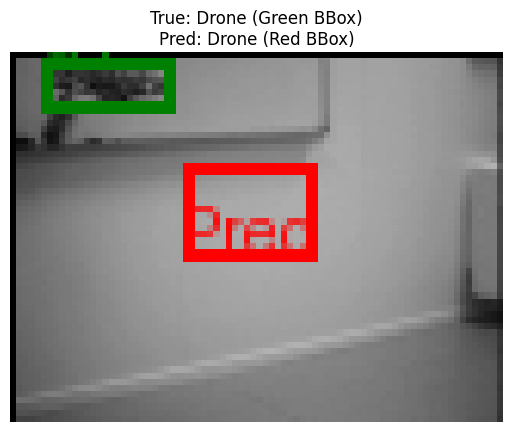

In [175]:
from PIL import Image, ImageDraw
import numpy as np

def visualize_prediction(model, X_sample, y_class_sample, y_bbox_sample, InputHeight, InputWidth):
    current_frame_path, diff_frame_path = X_sample

    # Preprocess the sample images
    current_frame_img_processed = preprocess_image(current_frame_path)
    diff_frame_img_processed = preprocess_image(diff_frame_path)

    # Add batch dimension for model prediction
    current_frame_input = tf.expand_dims(current_frame_img_processed, axis=0)
    diff_frame_input = tf.expand_dims(diff_frame_img_processed, axis=0)

    # Get model prediction
    pred_class, pred_bbox = model.predict([current_frame_input, diff_frame_input])

    # Process predicted classification
    predicted_label = 1 if pred_class[0][0] > 0.5 else 0
    predicted_bbox_coords = pred_bbox[0]

    # Load the current frame image for visualization
    img = Image.open(current_frame_path).convert('RGB')
    img_width, img_height = img.size
    draw = ImageDraw.Draw(img)

    # Draw Ground Truth Bounding Box (if drone present)
    true_label = y_class_sample
    true_bbox_coords = y_bbox_sample
    if true_label == 1 and any(b > 0 for b in true_bbox_coords):
        x_center, y_center, box_width, box_height = true_bbox_coords
        x_min = int((x_center - box_width / 2) * img_width)
        y_min = int((y_center - box_height / 2) * img_height)
        x_max = int((x_center + box_width / 2) * img_width)
        y_max = int((y_center + box_height / 2) * img_height)
        draw.rectangle([(x_min, y_min), (x_max, y_max)], outline='green', width=2)
        draw.text((x_min, y_min - 10), "GT", fill='green')

    # Draw Predicted Bounding Box (if predicted as drone)
    if predicted_label == 1:
        x_center, y_center, box_width, box_height = predicted_bbox_coords
        # Bounding box coordinates are usually normalized (0-1) and need to be scaled
        x_min = int((x_center - box_width / 2) * img_width)
        y_min = int((y_center - box_height / 2) * img_height)
        x_max = int((x_center + box_width / 2) * img_width)
        y_max = int((y_center + box_height / 2) * img_height)
        draw.rectangle([(x_min, y_min), (x_max, y_max)], outline='red', width=2)
        draw.text((x_min, y_min + 5), "Pred", fill='red')

    plt.imshow(img)
    plt.title(f"True: {'Drone' if true_label == 1 else 'Clear'} (Green BBox)\nPred: {'Drone' if predicted_label == 1 else 'Clear'} (Red BBox)")
    plt.axis('off')
    plt.show()

# Select a random sample from the test set
random_index = random.randint(0, len(X_test) - 1)
X_sample = X_test[random_index]
y_class_sample = y_classification_test[random_index]
y_bbox_sample = y_bbox_test[random_index]

# Visualize the prediction for the selected sample
visualize_prediction(model, X_sample, y_class_sample, y_bbox_sample, InputHeight, InputWidth)


# Full INT8 Post-Training Quantization (PTQ)

In [ ]:
# Use 100 samples from the training set as the representative dataset
x_rep = x_train[:100].reshape(-1, InputWidth, InputHeight)   # keep 2-D shape

def representative_dataset():
    for sample in x_rep:
        yield [sample[np.newaxis, :, :]]     # shape (1, InputWidth, InputHeight)

converter_ptq = tf.lite.TFLiteConverter.from_keras_model(model)
converter_ptq.optimizations = [tf.lite.Optimize.DEFAULT]
converter_ptq.representative_dataset = representative_dataset
converter_ptq.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_ptq.inference_input_type  = tf.int8
converter_ptq.inference_output_type = tf.int8

tflite_ptq = converter_ptq.convert()
open("model_ptq_int8.tflite", "wb").write(tflite_ptq)
print("PTQ INT8 model saved — size:", len(tflite_ptq), "bytes")

# Quantization-Aware Training (QAT)

In [ ]:
# 1. Wrap the trained model with QAT fake-quantization
# Note: tfmot.quantization.keras.quantize_model() requires a Functional model.
functional_model = keras.Model(inputs=model.input, outputs=model.output)
q_aware_model = tfmot.quantization.keras.quantize_model(functional_model)

q_aware_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)
q_aware_model.summary()

In [ ]:
# 2. Fine-tune for 5 epochs
q_aware_model.fit(
    x=x_train,
    y=y_train,
    batch_size=128,
    epochs=5,
    validation_split=0.1,
    verbose=1,
)

In [ ]:
# 3. Convert the QAT model to INT8 TFLite
converter_qat = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter_qat.optimizations = [tf.lite.Optimize.DEFAULT]
converter_qat.representative_dataset = representative_dataset
converter_qat.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_qat.inference_input_type  = tf.int8
converter_qat.inference_output_type = tf.int8

tflite_qat = converter_qat.convert()
open("model_qat_int8.tflite", "wb").write(tflite_qat)
print("QAT INT8 model saved — size:", len(tflite_qat), "bytes")

# Model Size Comparison

INT8 models store weights as 8-bit integers instead of 32-bit floats — roughly **4× smaller**. On a microcontroller with only tens of kilobytes of flash, this difference matters enormously.

In [ ]:
# Save the float model as TFLite for a fair comparison
converter_float = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float = converter_float.convert()
open("model_float32.tflite", "wb").write(tflite_float)

sizes = {
    "Float32 TFLite": os.path.getsize("model_float32.tflite"),
    "PTQ INT8      ": os.path.getsize("model_ptq_int8.tflite"),
    "QAT INT8      ": os.path.getsize("model_qat_int8.tflite"),
}

print(f"{'Model':<20} {'Size (bytes)':>14} {'Size (KB)':>10}")
print("-" * 46)
for name, size in sizes.items():
    print(f"{name:<20} {size:>14,} {size/1024:>9.1f}")

# Test TFLite Models

Test **sample-by-sample** — exactly how inference runs on a microcontroller. For INT8 models the input must be scaled from `float32` to `int8` using the quantization parameters reported by the interpreter.

In [ ]:
def evaluate_tflite(model_path, x, y_true, max_samples=1000):
    """Run TFLite inference sample-by-sample and return accuracy."""
    interpreter = litert.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_dtype = input_details[0]["dtype"]
    is_int8 = (input_dtype == np.int8)

    if is_int8:
        scale, zero_point = input_details[0]["quantization"]

    correct = 0
    for i in range(min(max_samples, len(x))):
        sample = x[i:i+1]                       # shape (1, 28, 28)

        if is_int8:
            sample = (sample / scale + zero_point).astype(np.int8)

        interpreter.set_tensor(input_details[0]["index"], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]["index"])
        pred = np.argmax(output[0])
        if pred == y_true[i]:
            correct += 1

    return correct / min(max_samples, len(x))

acc_ptq = evaluate_tflite("model_ptq_int8.tflite", x_test, y_test)
acc_qat = evaluate_tflite("model_qat_int8.tflite", x_test, y_test)

print(f"PTQ INT8 accuracy : {acc_ptq:.4f}")
print(f"QAT INT8 accuracy : {acc_qat:.4f}")

# Export as C Arrays

The `.tflite` binary is embedded in a C header as a `const` byte array. The MCU firmware reads this array directly from flash.

Good practices for MCU C headers:
- `#ifndef` / `#define` / `#endif` — prevent double-inclusion
- `alignas(16)` — ensures 16-byte alignment for SIMD-like hardware (e.g. DSP cores)
- `const` — allows the linker to place the array in read-only flash

In [ ]:
import binascii
import datetime

def to_c_array(data: bytes) -> str:
    """Convert bytes to a comma-separated C hex array, 12 bytes per line."""
    hexstr = binascii.hexlify(data).decode("ascii").upper()
    values = ["0x" + hexstr[i:i+2] for i in range(0, len(hexstr), 2)]
    lines  = [", ".join(values[i:i+12]) for i in range(0, len(values), 12)]
    return ",\n  ".join(lines)

def write_c_header(tflite_path: str, header_path: str, array_name: str, quant_type: str):
    data = open(tflite_path, "rb").read()
    guard = array_name.upper() + "_H"
    body = (
        f"// Auto-generated on {datetime.date.today()}\n"
        f"// Model: {tflite_path}  |  Quantization: {quant_type}  |  Size: {len(data)} bytes\n"
        f"#ifndef {guard}\n"
        f"#define {guard}\n"
        f"#include <stdint.h>\n"
        f"#include <stdalign.h>\n\n"
        f"alignas(16) const uint8_t {array_name}[] = {{\n  "
        + to_c_array(data) +
        f"\n}};\n"
        f"const unsigned int {array_name}_len = {len(data)};\n\n"
        f"#endif  // {guard}\n"
    )
    open(header_path, "w").write(body)
    print(f"Written {header_path}  ({len(data)} bytes)")

write_c_header("model_ptq_int8.tflite", "model_ptq_int8.h", "tf_model_ptq", "INT8 PTQ")
write_c_header("model_qat_int8.tflite", "model_qat_int8.h", "tf_model_qat", "INT8 QAT")